# 02 — Sleep-EDF Dataset Building

This notebook builds a compact subject-level sleep feature dataset from prepared Sleep-EDF hypnogram annotations.

## Objectives

- load the prepared hypnogram dataset;
- clean sleep-stage annotations;
- extract subject-level sleep features;
- save the processed feature table;
- save a simple processing log.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the project root by looking for README.md and data/."""
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Project root not found. Make sure README.md and data/ exist."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "notebooks" / "images"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

hypno_path = PROCESSED_DIR / "hypno_df.csv"
features_path = PROCESSED_DIR / "sleep_features_all_subjects.csv"
log_path = PROCESSED_DIR / "processing_log.csv"


## Load hypnogram data

The input file is expected at `data/processed/hypno_df.csv` and should contain sleep-stage labels and episode durations.


In [3]:
if not hypno_path.exists():
    raise FileNotFoundError(
        "Expected file not found: data/processed/hypno_df.csv. "
        "Create or place the prepared hypnogram file before running this notebook."
    )

hypno_df = pd.read_csv(hypno_path)

display(hypno_df.head())
display(pd.DataFrame({"column": hypno_df.columns, "dtype": hypno_df.dtypes.astype(str).values}))


,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0


,column,dtype
0,description,str
1,duration,float64


## Cleaning helpers

The helper functions below standardize column names, remove unknown annotations and keep only valid positive-duration episodes.


In [4]:
def standardize_hypnogram_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return a hypnogram with standardized description and duration columns."""
    df = df.copy()

    if "description" not in df.columns:
        possible_stage_columns = [
            "stage",
            "sleep_stage",
            "Sleep Stage",
            "annotation",
        ]

        stage_col = next((col for col in possible_stage_columns if col in df.columns), None)

        if stage_col is None:
            raise ValueError("Could not find a sleep-stage column.")

        df = df.rename(columns={stage_col: "description"})

    if "duration" not in df.columns:
        if "duration_sec" in df.columns:
            df = df.rename(columns={"duration_sec": "duration"})
        else:
            raise ValueError("Could not find a duration column.")

    df = df[["description", "duration"]].copy()
    df["description"] = df["description"].astype(str)
    df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

    return df


def clean_hypnogram(df: pd.DataFrame) -> pd.DataFrame:
    """Clean standardized hypnogram annotations."""
    df = standardize_hypnogram_columns(df)
    df = df.dropna(subset=["description", "duration"])
    df = df[~df["description"].str.contains("?", regex=False, na=False)]
    df = df[df["duration"] > 0]
    df = df.reset_index(drop=True)

    return df


clean_df = clean_hypnogram(hypno_df)

display(clean_df.head())
display(clean_df.describe(include="all"))


,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0


,description,duration
count,153,153.000000
unique,6,NaN
top,Sleep stage 3,NaN
freq,48,NaN
mean,NaN,519.607843
std,NaN,3295.552003
min,NaN,30.000000
25%,NaN,30.000000
50%,NaN,60.000000
75%,NaN,150.000000


## Feature extraction

Subject-level features summarize sleep duration, latency, sleep efficiency, fragmentation and sleep-stage proportions.


In [5]:
def find_sleep_boundaries(df: pd.DataFrame) -> tuple[int | None, int | None]:
    """Find first and last non-wake sleep-stage episodes."""
    sleep_mask = df["description"] != "Sleep stage W"

    if sleep_mask.sum() == 0:
        return None, None

    first_sleep_idx = df[sleep_mask].index[0]
    last_sleep_idx = df[sleep_mask].index[-1]

    return first_sleep_idx, last_sleep_idx


def extract_sleep_features(df: pd.DataFrame, subject_id: str) -> dict:
    """Extract subject-level sleep features from a cleaned hypnogram."""
    df = clean_hypnogram(df)

    total_recording_time_sec = df["duration"].sum()
    first_sleep_idx, last_sleep_idx = find_sleep_boundaries(df)

    base_features = {
        "subject_id": subject_id,
        "n_episodes": len(df),
        "recording_hours": total_recording_time_sec / 3600,
    }

    if first_sleep_idx is None:
        base_features.update({
            "sleep_period_hours": np.nan,
            "total_sleep_hours": 0.0,
            "sleep_latency_min": np.nan,
            "rem_latency_min": np.nan,
            "fragmentation": np.nan,
            "wake_pct_in_sleep_period": np.nan,
            "rem_pct_of_tst": np.nan,
            "n1_pct_of_tst": np.nan,
            "n2_pct_of_tst": np.nan,
            "deep_sleep_pct_of_tst": np.nan,
            "sleep_efficiency": np.nan,
        })
        return base_features

    sleep_latency_sec = (
        df.loc[: first_sleep_idx - 1, "duration"].sum()
        if first_sleep_idx > 0
        else 0
    )

    rem_indices = df[df["description"] == "Sleep stage R"].index
    rem_after_sleep = rem_indices[rem_indices >= first_sleep_idx]

    if len(rem_after_sleep) > 0:
        first_rem_idx = rem_after_sleep[0]
        rem_latency_sec = (
            df.loc[first_sleep_idx : first_rem_idx - 1, "duration"].sum()
            if first_rem_idx > first_sleep_idx
            else 0
        )
    else:
        rem_latency_sec = np.nan

    sleep_period_df = df.loc[first_sleep_idx:last_sleep_idx].copy().reset_index(drop=True)
    sleep_period_time_sec = sleep_period_df["duration"].sum()

    wake_in_sleep_period_sec = sleep_period_df.loc[
        sleep_period_df["description"] == "Sleep stage W", "duration"
    ].sum()

    total_sleep_time_sec = sleep_period_time_sec - wake_in_sleep_period_sec
    sleep_only_df = sleep_period_df[sleep_period_df["description"] != "Sleep stage W"]
    sleep_stage_time = sleep_only_df.groupby("description")["duration"].sum()

    if total_sleep_time_sec > 0:
        sleep_stage_pct = sleep_stage_time / total_sleep_time_sec * 100
    else:
        sleep_stage_pct = pd.Series(dtype=float)

    stage_transitions = (
        sleep_period_df["description"] != sleep_period_df["description"].shift()
    ).sum()

    features = {
        **base_features,
        "sleep_period_hours": sleep_period_time_sec / 3600,
        "total_sleep_hours": total_sleep_time_sec / 3600,
        "sleep_latency_min": sleep_latency_sec / 60,
        "rem_latency_min": rem_latency_sec / 60 if pd.notna(rem_latency_sec) else np.nan,
        "fragmentation": stage_transitions,
        "wake_pct_in_sleep_period": (
            wake_in_sleep_period_sec / sleep_period_time_sec * 100
            if sleep_period_time_sec > 0
            else np.nan
        ),
        "rem_pct_of_tst": sleep_stage_pct.get("Sleep stage R", 0.0),
        "n1_pct_of_tst": sleep_stage_pct.get("Sleep stage 1", 0.0),
        "n2_pct_of_tst": sleep_stage_pct.get("Sleep stage 2", 0.0),
        "deep_sleep_pct_of_tst": (
            sleep_stage_pct.get("Sleep stage 3", 0.0)
            + sleep_stage_pct.get("Sleep stage 4", 0.0)
        ),
        "sleep_efficiency": (
            total_sleep_time_sec / sleep_period_time_sec
            if sleep_period_time_sec > 0
            else np.nan
        ),
    }

    return features


In [6]:
subject_id = "subject_001"

features = extract_sleep_features(hypno_df, subject_id=subject_id)
features_df = pd.DataFrame([features])

display(features_df)


,subject_id,n_episodes,recording_hours,sleep_period_hours,total_sleep_hours,sleep_latency_min,rem_latency_min,fragmentation,wake_pct_in_sleep_period,rem_pct_of_tst,n1_pct_of_tst,n2_pct_of_tst,deep_sleep_pct_of_tst,sleep_efficiency
0,subject_001,153,22.083333,6.008333,5.441667,510.5,89.0,151,9.431345,19.14242,8.882083,38.284839,33.690658,0.905687


## Save processed dataset

The extracted feature table is saved for downstream feature engineering and analysis notebooks.


In [7]:
features_df.to_csv(features_path, index=False)

processing_log = pd.DataFrame([{
    "input_file": hypno_path.name,
    "output_file": features_path.name,
    "n_input_rows": len(hypno_df),
    "n_clean_rows": len(clean_df),
    "status": "success",
}])

processing_log.to_csv(log_path, index=False)

display(processing_log)
print(f"Saved features to: {features_path.relative_to(PROJECT_ROOT)}")
print(f"Saved log to: {log_path.relative_to(PROJECT_ROOT)}")


,input_file,output_file,n_input_rows,n_clean_rows,status
0,hypno_df.csv,sleep_features_all_subjects.csv,153,153,success


Saved features to: data\processed\sleep_features_all_subjects.csv
Saved log to: data\processed\processing_log.csv


## Visual check

The following plot summarizes selected sleep features in minutes, percentages or ratios.


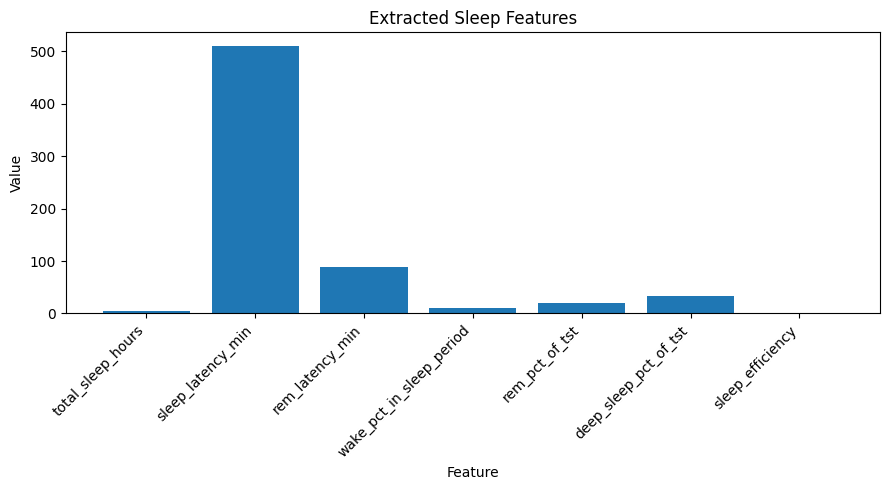

In [8]:
selected_features = [
    "total_sleep_hours",
    "sleep_latency_min",
    "rem_latency_min",
    "wake_pct_in_sleep_period",
    "rem_pct_of_tst",
    "deep_sleep_pct_of_tst",
    "sleep_efficiency",
]

plot_df = features_df[selected_features].T.reset_index()
plot_df.columns = ["feature", "value"]

plt.figure(figsize=(9, 5))
plt.bar(plot_df["feature"], plot_df["value"])
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Extracted Sleep Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = IMAGES_DIR / "02_extracted_sleep_features.png"
plt.savefig(plot_path, dpi=150)

plt.show()


## Summary

This notebook converts prepared hypnogram annotations into a compact sleep feature table. The resulting dataset can be used by later notebooks for feature engineering, sleep-health exploration and cognition-related analysis.
